# Credit Score Analysis - Paisabazaar Case Study

**Business Problem**

Paisabazaar is a financial services platform that helps customers compare and apply for various credit products such as loans and credit cards. One of the most important factors in financial decision-making is a customer's credit score, which indicates their creditworthiness and ability to repay debts.

Financial institutions rely heavily on credit scores to determine loan approvals, interest rates, and risk levels. Understanding the factors that influence credit scores can help Paisabazaar improve its credit assessment process, reduce financial risk, and provide better financial recommendations to its customers.

**Objective of the Analysis**

The objective of this project is to analyze customer financial data and identify key factors that influence credit scores. By performing exploratory data analysis (EDA), we aim to uncover relationships between credit scores and variables such as income, credit utilization, payment behavior, loan history, and financial discipline.

**Key Goals**

• Explore the dataset and understand its structure  
• Clean the data and handle missing or inconsistent values  
• Identify patterns and relationships affecting credit scores  
• Create visualizations to support insights  
• Provide business insights useful for financial decision-making


# Dataset Description


| Column                  | Description                                         |
|--------------------------|-----------------------------------------------------|
| Age                      | Age of the customer                                |
| Annual_Income            | Annual income of the customer                      |
| Monthly_Inhand_Salary    | Monthly salary received                            |
| Num_Bank_Accounts        | Number of bank accounts owned                      |
| Num_Credit_Card          | Number of credit cards owned                       |
| Num_of_Loan              | Total number of loans                              |
| Outstanding_Debt         | Total outstanding debt                             |
| Credit_Utilization_Ratio | Percentage of credit used                          |
| Num_of_Delayed_Payment   | Number of delayed payments                         |
| Credit_History_Age       | Length of credit history                           |
| Total_EMI_per_month      | Monthly EMI obligations                            |
| Amount_invested_monthly  | Monthly investment amount                          |
| Monthly_Balance          | Remaining monthly balance                          |
| Credit_Score             | Creditworthiness category (Good / Standard / Poor) |

# Libraries

In [47]:
# Importing Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)

# Load Dataset

In [48]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset (2).csv


In [49]:
# Loading data

df = pd.read_csv("dataset.csv")
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [50]:
df.shape

(100000, 28)

# Data Exploration

In [51]:
# column names

df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [52]:
# dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [53]:
# Statistical Summary
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,9.000000,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


In [54]:
# Last records
df.tail()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
99995,155625,37932,4,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",23.0,7.0,11.5,3.0,Good,502.38,34.663572,378.0,No,35.104023,24.028477,High_spent_Large_value_payments,479.866228,Poor
99996,155626,37932,5,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",18.0,7.0,11.5,3.0,Good,502.38,40.565631,379.0,No,35.104023,24.028477,High_spent_Medium_value_payments,496.651610,Poor
99997,155627,37932,6,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",27.0,6.0,11.5,3.0,Good,502.38,41.255522,380.0,No,35.104023,24.028477,High_spent_Large_value_payments,516.809083,Poor
99998,155628,37932,7,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",20.0,6.0,11.5,3.0,Good,502.38,33.638208,381.0,No,35.104023,24.028477,Low_spent_Large_value_payments,319.164979,Standard
99999,155629,37932,8,Nicks,25.0,78735990.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"Auto Loan, and Student Loan",18.0,6.0,11.5,3.0,Good,502.38,34.192463,382.0,No,35.104023,24.028477,High_spent_Medium_value_payments,393.673696,Poor


In [55]:
# Check Unique Values
df['Credit_Score'].unique()

array(['Good', 'Standard', 'Poor'], dtype=object)

In [56]:
# credit mix
df['Credit_Mix'].unique()

array(['Good', 'Standard', 'Bad'], dtype=object)

In [57]:
# Payment Behaviour
df['Payment_Behaviour'].unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments',
       'High_spent_Large_value_payments'], dtype=object)

In [58]:
# Payment of Minimum Amount
df['Payment_of_Min_Amount'].unique()

array(['No', 'NM', 'Yes'], dtype=object)

In [59]:
# Occupation
df['Occupation'].unique()

array(['Scientist', 'Teacher', 'Engineer', 'Entrepreneur', 'Developer',
       'Lawyer', 'Media_Manager', 'Doctor', 'Journalist', 'Manager',
       'Accountant', 'Musician', 'Mechanic', 'Writer', 'Architect'],
      dtype=object)

Age Values

In [60]:
# Check for Impossible Age Values

df['Age'].describe()

,Age
count,100000.000000
mean,33.316340
std,10.764812
min,14.000000
25%,24.000000
50%,33.000000
75%,42.000000
max,56.000000


In [61]:
df['Age'].sort_values().head()

,Age
72659,14.0
72658,14.0
72657,14.0
72656,14.0
52501,14.0


Check Income Distribution

In [62]:
df['Annual_Income'].describe()

,Annual_Income
count,100000.000000
mean,50505.123449
std,38299.422093
min,7005.930000
25%,19342.972500
50%,36999.705000
75%,71683.470000
max,179987.280000


In [63]:
df['Annual_Income'].sort_values().head()

,Annual_Income
39672,7005.93
39673,7005.93
39674,7005.93
39675,7005.93
39676,7005.93


Credit Utilization

In [64]:
df['Credit_Utilization_Ratio'].describe()

,Credit_Utilization_Ratio
count,100000.000000
mean,32.285173
std,5.116875
min,20.000000
25%,28.052567
50%,32.305784
75%,36.496663
max,50.000000


Delayed payments

In [65]:
df['Num_of_Delayed_Payment'].describe()

,Num_of_Delayed_Payment
count,100000.000000
mean,13.313120
std,6.237166
min,0.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,25.000000


# Data Cleaning

Missing Values

In [66]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


**Duplicate Rows**

In [67]:
df.duplicated().sum()

np.int64(0)

**Dropping Irrelevant Columns**

In [68]:
df = df.drop(['ID','Customer_ID','Name','SSN'], axis=1)

df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,4.0,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.0,4.0,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [69]:
df.shape

(100000, 24)

# **Exploratory Data Analysis**

**Credit Score Distribution**

In [70]:
df['Credit_Score'].value_counts()

,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


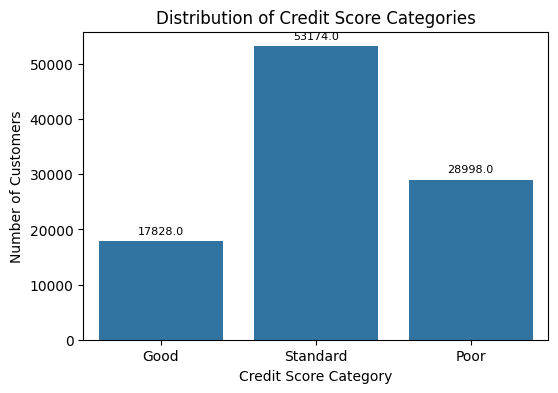

In [71]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Credit_Score', data=df)

plt.title("Distribution of Credit Score Categories")
plt.xlabel("Credit Score Category")
plt.ylabel("Number of Customers")

# Add data labels
for p in ax.patches:
    ax.annotate(
        str(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='baseline',
        fontsize= 8, color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.show()

**Visualization 2**
**Annual Income vs Credit Score**

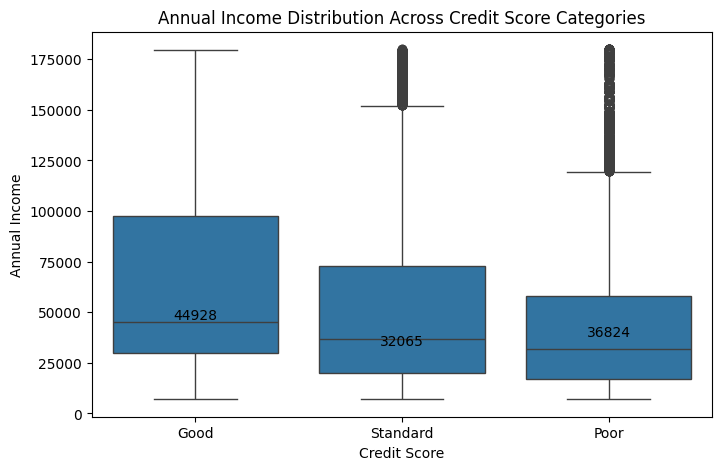

In [72]:
plt.figure(figsize=(8,5))
ax = sns.boxplot(x='Credit_Score', y='Annual_Income', data=df)

plt.title("Annual Income Distribution Across Credit Score Categories")
plt.xlabel("Credit Score")
plt.ylabel("Annual Income")

# Calculate medians for each category
medians = df.groupby('Credit_Score')['Annual_Income'].median()

# Add median labels
for i, category in enumerate(medians.index):
    median_val = medians[category]
    ax.text(i, median_val, f'{median_val:.0f}',
            ha='center', va='bottom', fontsize=10, color='black')

plt.show()

**Visualization 3 :**
**Credit Utilization vs Credit Score**

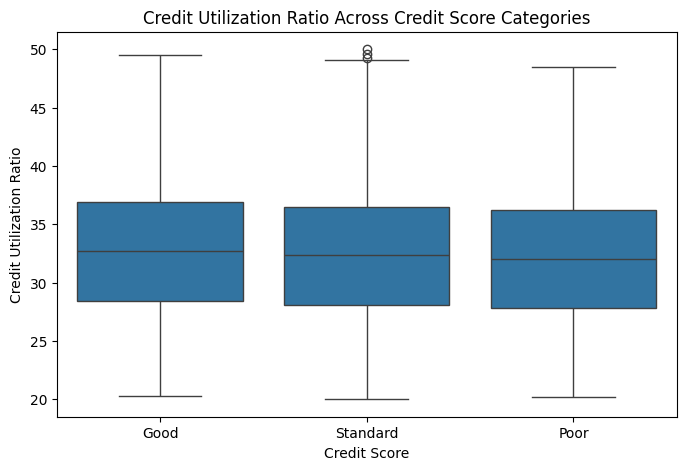

In [73]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Score', y='Credit_Utilization_Ratio', data=df)

plt.title("Credit Utilization Ratio Across Credit Score Categories")
plt.xlabel("Credit Score")
plt.ylabel("Credit Utilization Ratio")

plt.show()

**Visualization 4:**
**Delayed Payments vs Credit Score**

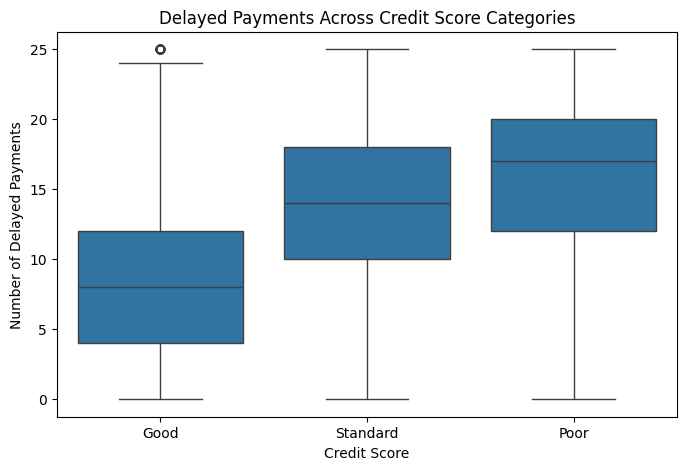

In [74]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Score', y='Num_of_Delayed_Payment', data=df)

plt.title("Delayed Payments Across Credit Score Categories")
plt.xlabel("Credit Score")
plt.ylabel("Number of Delayed Payments")

plt.show()

**Visualization 5:**
**Credit History Age vs Credit Score**

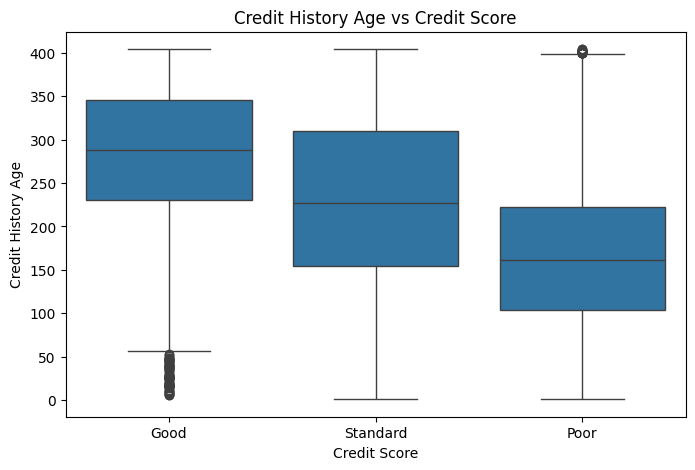

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Credit_Score', y='Credit_History_Age', data=df)

plt.title("Credit History Age vs Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Credit History Age")

plt.show()

**SUMMARY SO FAR**

* Most customers belong to the Standard credit score category.

* Customers with higher income tend to have better credit scores.

* Delayed payments strongly correlate with poorer credit scores.

* Customers with longer credit histories tend to have better credit scores.

* Credit utilization appears less distinct across score categories in this dataset.






# Correlation Analysis

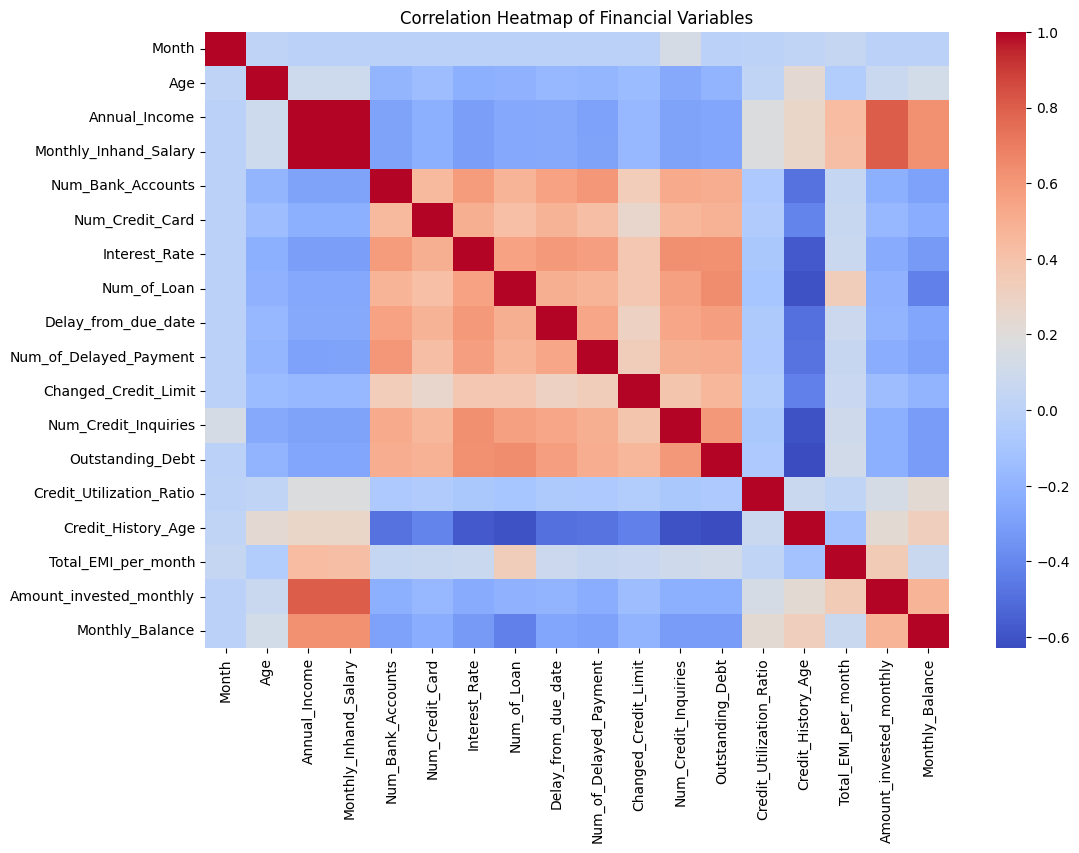

In [76]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)

plt.title("Correlation Heatmap of Financial Variables")

plt.show()

**Payment Behaviour vs Credit Score**

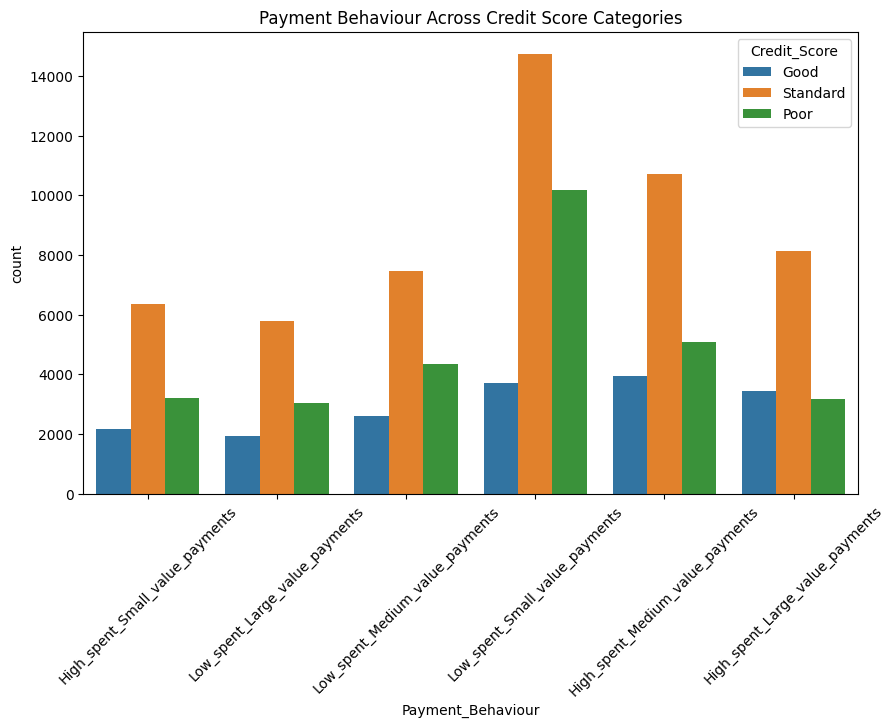

In [77]:
plt.figure(figsize=(10,6))

sns.countplot(x='Payment_Behaviour', hue='Credit_Score', data=df)

plt.xticks(rotation=45)

plt.title("Payment Behaviour Across Credit Score Categories")

plt.show()

**EMI vs Monthly Balance**

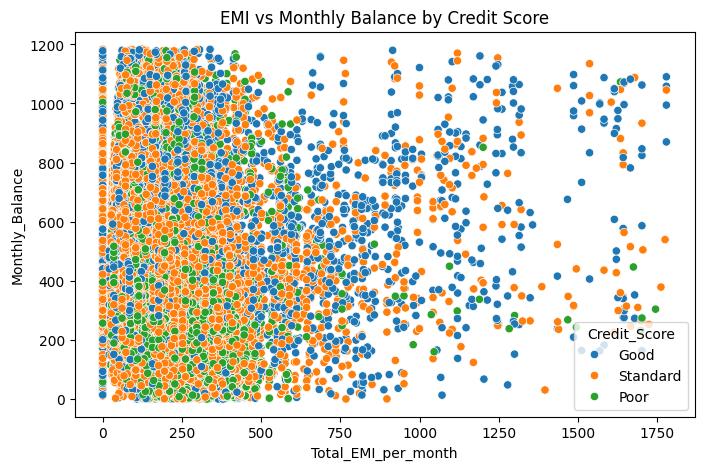

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Total_EMI_per_month', y='Monthly_Balance', hue='Credit_Score', data=df)

plt.title("EMI vs Monthly Balance by Credit Score")

plt.show()

# Customer Segmentation Analysis

**Createing Age Groups**

In [79]:
# Creating Age Groups

bins = [0, 25, 35, 45, 60]
labels = ['18-25', '26-35', '36-45', '46-60']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df[['Age','Age_Group']].head()

,Age,Age_Group
0,23.0,18-25
1,23.0,18-25
2,23.0,18-25
3,23.0,18-25
4,23.0,18-25


**Visualization: Age Group vs Credit Score**

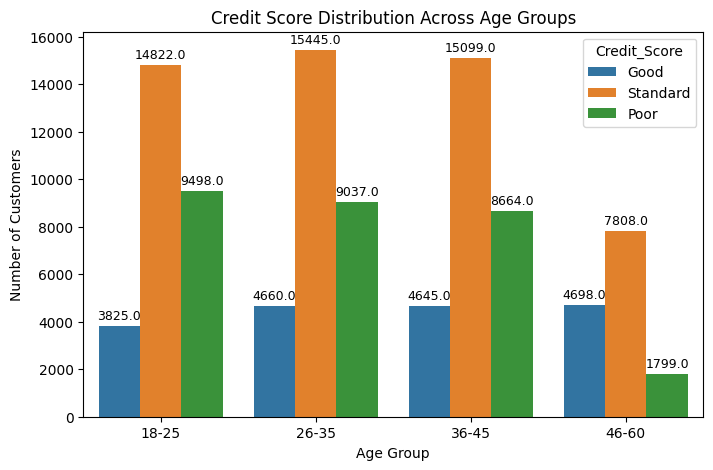

In [80]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Age_Group', hue='Credit_Score', data=df)

plt.title("Credit Score Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label non-empty bars
        ax.annotate(
            str(height),
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='baseline',
            fontsize=9, color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.show()

**Credit Mix vs Credit Score**

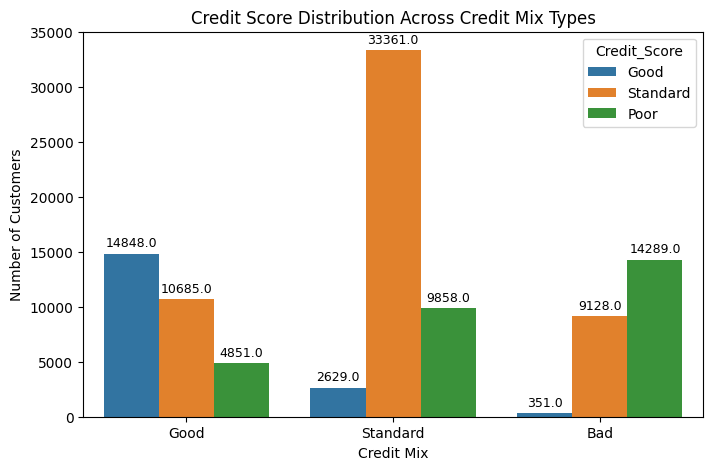

In [81]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Credit_Mix', hue='Credit_Score', data=df)

plt.title("Credit Score Distribution Across Credit Mix Types")
plt.xlabel("Credit Mix")
plt.ylabel("Number of Customers")

# Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label non-empty bars
        ax.annotate(
            str(height),
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='baseline',
            fontsize=9, color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )

plt.show()

# Key Insights

* Credit Score Distribution

The majority of customers fall into the Standard credit score category (53,174 customers), followed by Poor (28,998) and Good (17,828).
This indicates that more than half of the customer base has moderate creditworthiness.

* Income and Credit Score Relationship

Customers with Good credit scores show the highest median annual income (~44,928) compared to Standard (~32,065) and Poor (~36,824) categories.
This suggests that higher income contributes to improved creditworthiness.

* Payment Discipline as a Major Factor

The median number of delayed payments increases significantly across credit score categories:

Good: ~8 delayed payments

Standard: ~14 delayed payments

Poor: ~17 delayed payments

This indicates that payment discipline is one of the strongest predictors of credit score quality.

* Credit History Length

Customers with Good credit scores tend to have longer credit histories (median ~290 months) compared to Standard (~230 months) and Poor (~160 months).
This shows that long-term credit experience positively impacts credit scores.

* Age and Credit Score

Younger customers (18–25) show 9,498 Poor credit scores, while the older age group (46–60) shows only 1,799 Poor scores.
This suggests that creditworthiness improves with age and financial experience.

* Credit Mix Influence

Customers with Bad credit mix show the highest number of Poor credit scores (14,289), whereas customers with Good credit mix show the highest number of Good scores (14,848).
This indicates that maintaining a balanced mix of credit products positively affects credit score quality.

* Financial Stress Indicators

Customers with higher monthly EMI obligations tend to maintain lower monthly balances, indicating financial pressure that could increase default risk.



# **Recommendations**


* Focus on Payment Behaviour

Since delayed payments increase significantly from ~8 to ~17 across credit score levels, financial institutions should prioritize monitoring customers with frequent payment delays.

* Encourage Responsible Credit Mix

Customers with good credit mix are far more likely to maintain good credit scores, suggesting that financial advisors should guide customers toward maintaining a balanced credit portfolio.

* Identify High-Risk Customers Early

Customers with high EMI obligations and low monthly balance should be flagged as potential high-risk borrowers.

*Support Younger Customers

Younger customers (18–25) show higher numbers of poor credit scores, indicating the need for financial education and responsible credit usage programs.

# Conclusion

* This study analyzed 100,000 customer financial records to identify the key drivers of credit score variation. Payment behavior, credit history length, income level, and credit mix emerged as the most influential factors.

* Customers with higher incomes, longer credit histories, and consistent repayment patterns consistently achieved stronger credit scores.

* Demographic analysis shows older customers generally maintain healthier credit profiles, while younger segments are more prone to poor scores.

* A balanced credit portfolio also strongly correlates with higher credit ratings.

These insights enable financial institutions such as Paisabazaar to refine credit evaluation processes, better identify high risk customers, and deliver more personalized financial product recommendations
on, and design more effective financial product offerings.

